## Trade Backtesting

Backtest VWAP Reclaim trades using predictions, scalp only, and oracle with 100% accuracy.

For backtesting, the following trade risk will be applied:
- Scalp Only: 750/trade
- Adaptive: 750 /trade or 1500/trade based on predictions
- Oracle: 750/trade or 1500/trade based on labels

In [18]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [19]:
# parameters
SCALP_RISK  = 750
HOLD_RISK   = 1500
SCALP_R_CAP =  0.75
HOLD_R_CAP  =  2.5

In [20]:
# load predictions
df = pd.read_csv('entry_predictions.csv')
df['date_ny'] = pd.to_datetime(df['date_ny'])

# extract test only
test = df[df['split'] == 'test'].copy().reset_index(drop=True)

print(f"Test trades          : {len(test)}")
print(f"Date range           : {test['date_ny'].min().date()} → {test['date_ny'].max().date()}")
print(f"\nActual follow-through : {test['follow_through'].sum()} ({test['follow_through'].mean():.1%})")
print(f"Predicted Hold        : {test['pred_follow_through'].sum()} ({test['pred_follow_through'].mean():.1%})")
print(f"\nSymbol distribution:")
print(test['symbol'].value_counts())

Test trades          : 251
Date range           : 2025-10-23 → 2026-02-27

Actual follow-through : 63 (25.1%)
Predicted Hold        : 58 (23.1%)

Symbol distribution:
symbol
PLTR    58
OKLO    53
TSLA    53
NVDA    44
COIN    43
Name: count, dtype: int64


In [21]:
# simulate P&L

# scalp only trades
test['pnl_fixed'] = test['R_scalp'] * SCALP_RISK

# adaptive trades
test['mode_adaptive'] = test['pred_follow_through'].map({1: 'Hold', 0: 'Scalp'})
test['risk_adaptive'] = test['pred_follow_through'].map({1: HOLD_RISK, 0: SCALP_RISK})
test['R_adaptive']    = test.apply(
    lambda r: r['R_hold'] if r['pred_follow_through'] == 1 else r['R_scalp'], axis=1
)
test['pnl_adaptive']  = test['R_adaptive'] * test['risk_adaptive']

# hold only
test['pnl_hold_only'] = test.apply(
    lambda r: r['R_hold'] * HOLD_RISK if r['pred_follow_through'] == 1 else 0, axis=1
)
test['cum_pnl_hold_only'] = test['pnl_hold_only'].cumsum()

# oracle trades
test['pnl_oracle'] = test['R_oracle'] * test['risk_oracle']

# cumulative P&L
test = test.sort_values('date_ny').reset_index(drop=True)
test['cum_pnl_fixed']    = test['pnl_fixed'].cumsum()
test['cum_pnl_adaptive'] = test['pnl_adaptive'].cumsum()
test['cum_pnl_oracle']   = test['pnl_oracle'].cumsum()

In [22]:
# summary stats
def strategy_summary(pnl_col, r_col, risk_col, label):
    pnl  = test[pnl_col]
    r    = test[r_col]
    risk = test[risk_col] if isinstance(risk_col, str) else risk_col

    total_pnl  = pnl.sum()
    win_rate   = (pnl > 0).mean()
    avg_r      = r.mean()
    avg_win    = pnl[pnl > 0].mean() if (pnl > 0).any() else 0
    avg_loss   = pnl[pnl < 0].mean() if (pnl < 0).any() else 0
    sharpe     = pnl.mean() / pnl.std() * np.sqrt(252) if pnl.std() > 0 else 0

    print(f"  {label}")
    print(f"  Total P&L   : ${total_pnl:>10,.0f}")
    print(f"  Win Rate    : {win_rate:>10.1%}")
    print(f"  Avg R       : {avg_r:>10.3f}")
    print(f"  Avg Win     : ${avg_win:>10,.0f}")
    print(f"  Avg Loss    : ${avg_loss:>10,.0f}")
    print(f"  Sharpe      : {sharpe:>10.3f}")


print("BACKTEST RESULTS:")
strategy_summary('pnl_fixed',    'R_scalp',    SCALP_RISK,      'SCALP ONLY:')
strategy_summary('pnl_adaptive', 'R_adaptive', 'risk_adaptive', 'ADAPTIVE:')
strategy_summary('pnl_hold_only', 'R_hold', HOLD_RISK, 'HOLD-ONLY (no scalps)')
strategy_summary('pnl_oracle',   'R_oracle',   'risk_oracle',   'ORACLE:')

BACKTEST RESULTS:
  SCALP ONLY:
  Total P&L   : $   -20,653
  Win Rate    :      35.5%
  Avg R       :     -0.110
  Avg Win     : $     1,114
  Avg Loss    : $      -739
  Sharpe      :     -1.463
  ADAPTIVE:
  Total P&L   : $    24,081
  Win Rate    :      36.7%
  Avg R       :      0.010
  Avg Win     : $     1,800
  Avg Loss    : $      -890
  Sharpe      :      1.015
  HOLD-ONLY (no scalps)
  Total P&L   : $    44,359
  Win Rate    :      10.4%
  Avg R       :     -0.023
  Avg Win     : $     3,552
  Avg Loss    : $    -1,500
  Sharpe      :      2.203
  ORACLE:
  Total P&L   : $    80,972
  Win Rate    :      39.8%
  Avg R       :      0.151
  Avg Win     : $     2,113
  Avg Loss    : $      -863
  Sharpe      :      3.037


In [24]:
# gap analysis
fixed_pnl    = test['pnl_fixed'].sum()
adaptive_pnl = test['pnl_adaptive'].sum()
hold_only_pnl = test['pnl_hold_only'].sum()
oracle_pnl   = test['pnl_oracle'].sum()
gap_closed   = (adaptive_pnl - fixed_pnl) / (oracle_pnl - fixed_pnl) * 100 if oracle_pnl != fixed_pnl else 0

print(f"  Oracle ceiling   : ${oracle_pnl:>10,.0f}")
print(f"  Adaptive gain    : ${adaptive_pnl - fixed_pnl:>+10,.0f} vs Scalp Only")
print(f"  Hold Only        : ${hold_only_pnl - fixed_pnl:>+10,.0f} vs Scalp Only")
print(f"  Gap closed       : {gap_closed:.1f}%")
print(f"  Hold-Only gap closed: {(hold_only_pnl - fixed_pnl) / (oracle_pnl - fixed_pnl) * 100:.1f}%")

  Oracle ceiling   : $    80,972
  Adaptive gain    : $   +44,734 vs Scalp Only
  Hold Only        : $   +65,013 vs Scalp Only
  Gap closed       : 44.0%
  Hold-Only gap closed: 64.0%


The model drastically improved realized P&L on unseen data. Win Rate did not change much but because more hold trades were deployed, average win P&L jumped almost $700. Risk adjusted returns went from deep negative to strong positive (-1463 to 1015).

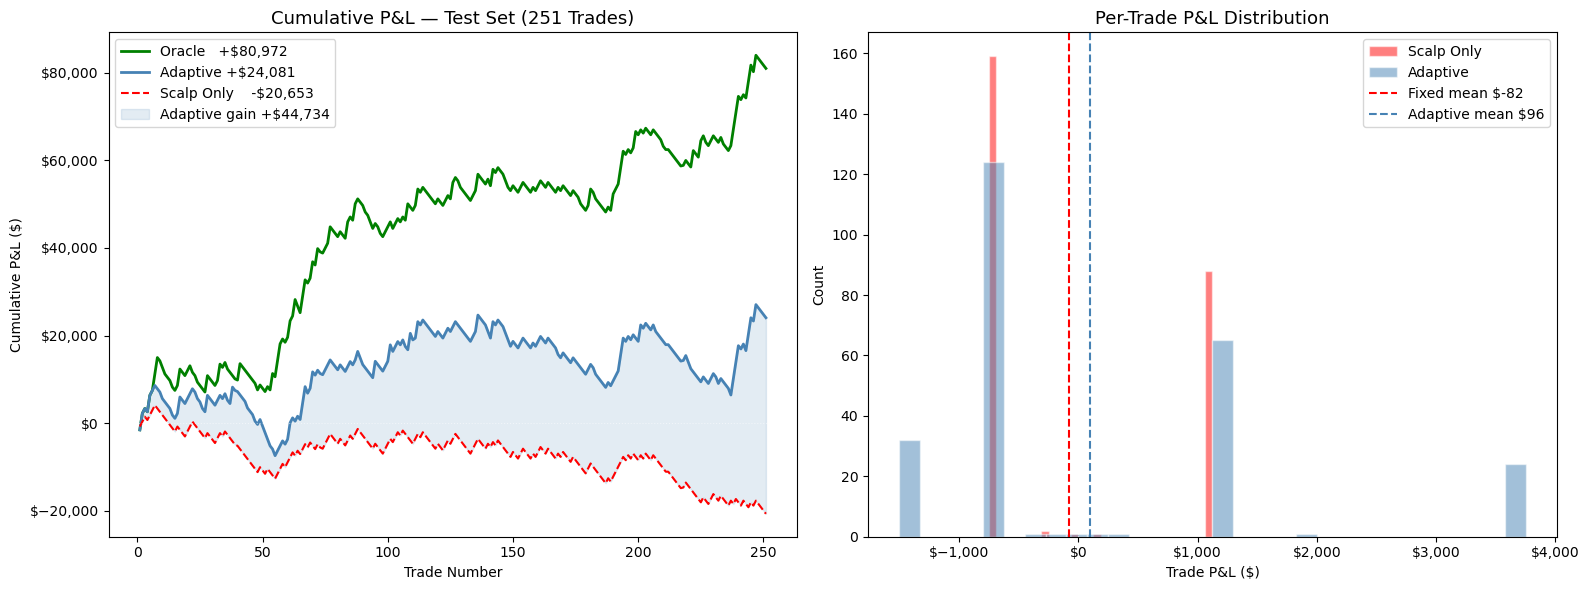

In [31]:
# cumulative P&L Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

trade_idx = range(1, len(test) + 1)

# Cumulative P&L curves
axes[0].plot(trade_idx, test['cum_pnl_oracle'],   color='green',     linewidth=2,   label=f"Oracle   +${oracle_pnl:,.0f}")
axes[0].plot(trade_idx, test['cum_pnl_adaptive'],  color='steelblue', linewidth=2,   label=f"Adaptive +${adaptive_pnl:,.0f}")
axes[0].plot(trade_idx, test['cum_pnl_fixed'],     color='red',       linewidth=1.5, linestyle='--', label=f"Scalp Only    -${abs(fixed_pnl):,.0f}")
axes[0].axhline(0, color='white', linestyle=':', linewidth=0.8, alpha=0.5)
axes[0].fill_between(trade_idx, test['cum_pnl_adaptive'], test['cum_pnl_fixed'],
                     alpha=0.15, color='steelblue', label=f'Adaptive gain +${adaptive_pnl - fixed_pnl:,.0f}')
axes[0].set_title('Cumulative P&L — Test Set (251 Trades)', fontsize=13)
axes[0].set_xlabel('Trade Number')
axes[0].set_ylabel('Cumulative P&L ($)')
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
axes[0].legend(loc='upper left')

# per trade P&L distribution
axes[1].hist(test['pnl_fixed'],    bins=30, alpha=0.5, color='red',       label='Scalp Only',    edgecolor='white')
axes[1].hist(test['pnl_adaptive'], bins=30, alpha=0.5, color='steelblue', label='Adaptive', edgecolor='white')
axes[1].axvline(0,                  color='white', linestyle=':', linewidth=0.8)
axes[1].axvline(test['pnl_fixed'].mean(),    color='red',       linestyle='--', linewidth=1.5, label=f"Fixed mean ${test['pnl_fixed'].mean():,.0f}")
axes[1].axvline(test['pnl_adaptive'].mean(), color='steelblue', linestyle='--', linewidth=1.5, label=f"Adaptive mean ${test['pnl_adaptive'].mean():,.0f}")
axes[1].set_title('Per-Trade P&L Distribution', fontsize=13)
axes[1].set_xlabel('Trade P&L ($)')
axes[1].set_ylabel('Count')
axes[1].xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
axes[1].legend()

plt.tight_layout()
plt.savefig('backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()

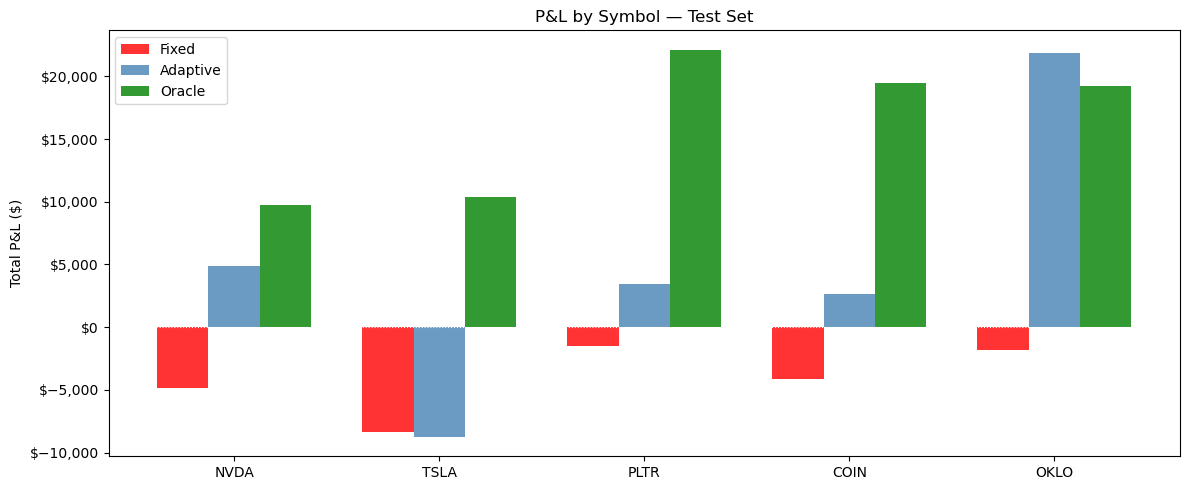

In [30]:
# P&L breakdown by stock
fig, ax = plt.subplots(figsize=(12, 5))
symbols    = test['symbol'].unique()
x          = np.arange(len(symbols))
width      = 0.25

fixed_vals    = [test[test['symbol']==s]['pnl_fixed'].sum()    for s in symbols]
adaptive_vals = [test[test['symbol']==s]['pnl_adaptive'].sum() for s in symbols]
oracle_vals   = [test[test['symbol']==s]['pnl_oracle'].sum()   for s in symbols]

ax.bar(x - width, fixed_vals,    width, label='Fixed',    color='red',       alpha=0.8)
ax.bar(x,         adaptive_vals, width, label='Adaptive', color='steelblue', alpha=0.8)
ax.bar(x + width, oracle_vals,   width, label='Oracle',   color='green',     alpha=0.8)
ax.axhline(0, color='white', linestyle=':', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(symbols)
ax.set_title('P&L by Symbol — Test Set')
ax.set_ylabel('Total P&L ($)')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
tp = test[(test['pred_follow_through']==1) & (test['follow_through']==1)]
fp = test[(test['pred_follow_through']==1) & (test['follow_through']==0)]
tn = test[(test['pred_follow_through']==0) & (test['follow_through']==0)]
fn = test[(test['pred_follow_through']==0) & (test['follow_through']==1)]

print("  CONFUSION-WEIGHTED P&L BREAKDOWN")

for label, subset, mode in [
    ('True Positive  (correct Hold)',  tp, 'Hold mode — follow-through detected'),
    ('False Positive (wrong Hold)',    fp, 'Hold mode — no follow-through'),
    ('True Negative  (correct Scalp)', tn, 'Scalp mode — correctly avoided'),
    ('False Negative (missed Hold)',   fn, 'Scalp mode — missed follow-through'),
]:
    if len(subset) == 0:
        continue
    pnl = subset['pnl_adaptive'].sum()
    avg = subset['pnl_adaptive'].mean()
    print(f"\n  {label}")
    print(f"  {mode}")
    print(f"  Count: {len(subset):>4}  |  Total P&L: ${pnl:>9,.0f}  |  Avg: ${avg:>7,.0f}")

print(f"  Net Adaptive P&L : ${test['pnl_adaptive'].sum():>10,.0f}")

  CONFUSION-WEIGHTED P&L BREAKDOWN

  True Positive  (correct Hold)
  Hold mode — follow-through detected
  Count:   29  |  Total P&L: $   56,250  |  Avg: $  1,940

  False Positive (wrong Hold)
  Hold mode — no follow-through
  Count:   29  |  Total P&L: $  -11,891  |  Avg: $   -410

  True Negative  (correct Scalp)
  Scalp mode — correctly avoided
  Count:  159  |  Total P&L: $  -19,153  |  Avg: $   -120

  False Negative (missed Hold)
  Scalp mode — missed follow-through
  Count:   34  |  Total P&L: $   -1,125  |  Avg: $    -33
  Net Adaptive P&L : $    24,081
